# OND trigger design : any river in its own top seasons

Trigger spec (working group, 29 Sep 2026; per-river depth adjusted 30 Sep 2026):
- WHERE: the river basin / zone pairs the EDRMC Bega flood alert lists as at risk
  of riverine flooding: Wabi Shebelle (Shebelle zone) | Genale Dawa (Afder, Liben,
  Dawa) | lower Omo Gibe (South Omo) | Bilate (Sidama, West Guji) | Kulfo, Slena
  and Sego (Gamo) | Akobo (Agnewak) | Baro (Itang, Nuwer, Agnewak).
- WHEN: OND only (October to December).
- SHAPE: one trigger across all areas; RANKING PER RIVER (working group: not a
  national ranking). For each river, its own OND seasons 2003 to 2025 are ranked
  by the river's seasonal peak; the threshold starts at the level of its
  3rd-largest season and is then LOWERED to also catch lower-ranked seasons that
  fall in the overall (any-river) activation years, stopping at the first season
  outside them, so no river can bring a new year into the union.
- Trigger: reached when any river is at or over its threshold. The top-3 depth
  was chosen so the OVERALL (any-river) frequency lands on the 1-in-3 spec:
  ranking each river's top third instead gives a union of 18 activations in 23
  years (1-in-1.3), which the working group rejected against the spec; the
  alternatives considered are in the depth-choice section below
  (any river top 4: 1-in-2.4 | 3 of 7 rivers in their top third: 1-in-2.4 |
  4 of 7: 1-in-4.0). The downward adjustment (30 Sep 2026) changes no overall
  activation year: it extends Genale Dawa and Baro to 2019 and Akobo to 2008,
  taking those rivers from 1-in-8 to 1-in-6 individually.

Method detail: a river's season statistic is the maximum over its stations of
(the station's OND daily maximum in that season / the station's median OND
seasonal maximum). Ranking this normalised statistic lets stations of very
different size (Dolow ~1800 m3/s, Webe Gestro ~200) carry equal weight inside
one river system. The river's threshold ratio is the smallest season statistic
among its kept seasons (top 3, extended within the union years); each station's
threshold in m3/s is that ratio times the station's median OND seasonal maximum.

Record: GloFAS v4 reanalysis (the version the operational forecast runs),
channel-snapped cells, OND 2003 to 2025.

Coverage notes, stated for the record: the Kulfo, Slena and Sego at Arba Minch
are below GloFAS's 0.05 degree resolution; the Gamo station is the Abaya-Chamo
lake system cell and is labelled as such. The Dawa is monitored by a dedicated
cell in Daawa zone; Dolow sits below the Genale-Dawa confluence.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import ocha_stratus as stratus
import pandas as pd

pd.set_option("display.max_colwidth", None)

STAGE = "dev"
PROJECT_PREFIX = "ds-aa-eth-flooding"
OND = [10, 11, 12]
YEARS = list(range(2003, 2026))
N_YEARS = len(YEARS)
TOP_N = 3  # per-river depth; chosen so the any-river union is 1-in-3 overall

RIVER_OF = {
    "station_1": "Wabi Shebelle", "station_2": "Wabi Shebelle", "station_3": "Wabi Shebelle",
    "station_4": "Wabi Shebelle", "G1904": "Wabi Shebelle",
    "RP_4045_0535": "Genale Dawa", "RP_4205_0415": "Genale Dawa",
    "station_5": "Genale Dawa", "dawa_1": "Genale Dawa",
    "omo_1": "Omo", "bilate_1": "Bilate", "gamo_1": "Gamo lakes",
    "baro_1": "Baro", "akobo_1": "Akobo",
}
RIVERS = ["Wabi Shebelle", "Genale Dawa", "Omo", "Bilate", "Gamo lakes", "Baro", "Akobo"]

## Load the OND reanalysis, all 14 stations

In [2]:
frames = []
for blob in ["glofas_discharge.parquet", "glofas_discharge_reporting_points.parquet"]:
    df = stratus.load_parquet_from_blob(f"{PROJECT_PREFIX}/processed/glofas/{blob}", stage=STAGE)
    df = df[df["dataset"] == "reanalysis"]
    frames.append(df[["station_id", "valid_time", "discharge"]])
nb_ = stratus.load_parquet_from_blob(
    f"{PROJECT_PREFIX}/processed/glofas/glofas_discharge_newbasins_ond.parquet", stage=STAGE
)
frames.append(nb_[["station_id", "valid_time", "discharge"]])
rean = pd.concat(frames, ignore_index=True)
rean["valid_time"] = pd.to_datetime(rean["valid_time"]).dt.normalize()
rean["date"] = rean["valid_time"] - pd.Timedelta(days=1)
rean = rean.sort_values("valid_time").drop_duplicates(["station_id", "date"], keep="last")
ond = rean[rean["date"].dt.month.isin(OND) & rean["date"].dt.year.isin(YEARS)]
daily = ond.pivot_table(index="date", columns="station_id", values="discharge")
print(daily.shape, "|", sorted(daily.columns))

(2116, 14) | ['G1904', 'RP_4045_0535', 'RP_4205_0415', 'akobo_1', 'baro_1', 'bilate_1', 'dawa_1', 'gamo_1', 'omo_1', 'station_1', 'station_2', 'station_3', 'station_4', 'station_5']


## Per-river season statistic and thresholds

In [3]:
seas_max = daily.groupby(daily.index.year).max()          # station OND max per season
med_max = seas_max.median()                                # station median OND seasonal max
norm = seas_max / med_max                                  # normalised seasonal peaks

river_stat = pd.DataFrame({
    r: norm[[s for s, rr in RIVER_OF.items() if rr == r and s in norm.columns]].max(axis=1)
    for r in RIVERS
})

# start at the top-3 depth, then lower each river's ratio to also catch
# lower-ranked seasons that are already overall activation years; stop at the
# first season outside the union, so no river can bring a new year in and the
# overall activation years are unchanged by construction (adjusted 30 Sep 2026)
ratio_top3 = river_stat.apply(lambda col: col.sort_values(ascending=False).iloc[TOP_N - 1])
active_top3 = river_stat.ge(ratio_top3, axis=1)
union_top3 = set(active_top3.index[active_top3.any(axis=1)])
adj = {}
for r in RIVERS:
    ranked = river_stat[r].sort_values(ascending=False)
    keep = list(ranked.index[:TOP_N])
    for y in ranked.index[TOP_N:]:
        if y not in union_top3:
            break
        keep.append(y)
    adj[r] = ranked.loc[keep].min()
ratio_star = pd.Series(adj)[RIVERS]

comp = pd.DataFrame({"top3_ratio": ratio_top3, "adjusted_ratio": ratio_star}).round(3)
comp["seasons_kept"] = [int(river_stat[r].ge(ratio_star[r]).sum()) for r in RIVERS]
print("threshold ratio per river (3rd-largest, lowered within the union years):")
print(comp.to_string())

levels = pd.DataFrame({
    "station_id": med_max.index,
    "river": [RIVER_OF[s] for s in med_max.index],
    "median_ond_max_m3s": med_max.round(1).values,
}).set_index("station_id")
levels["threshold_m3s"] = (med_max * levels["river"].map(ratio_star)).round(1)
levels.sort_values(["river", "station_id"])

threshold ratio per river (3rd-largest, lowered within the union years):
               top3_ratio  adjusted_ratio  seasons_kept
Wabi Shebelle       1.227           1.227             3
Genale Dawa         1.512           1.500             4
Omo                 1.269           1.269             3
Bilate              1.528           1.528             3
Gamo lakes          1.531           1.531             3
Baro                1.259           1.242             4
Akobo               1.291           1.290             4


,river,median_ond_max_m3s,threshold_m3s
station_id,,,
akobo_1,Akobo,284.899994,367.600006
baro_1,Baro,1601.000000,1988.800049
bilate_1,Bilate,142.100006,217.199997
gamo_1,Gamo lakes,461.600006,706.500000
RP_4045_0535,Genale Dawa,526.900024,790.000000
RP_4205_0415,Genale Dawa,1558.500000,2337.000000
dawa_1,Genale Dawa,279.700012,419.399994
station_5,Genale Dawa,193.199997,289.600006
omo_1,Omo,3806.399902,4830.000000


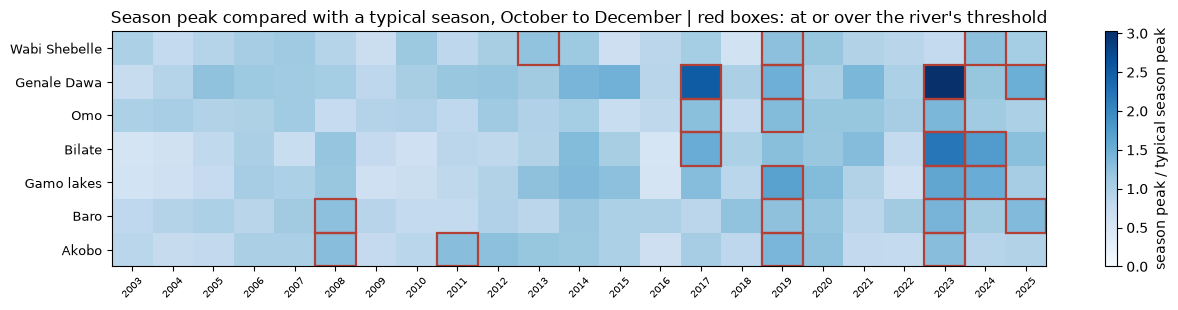

In [4]:
fig, ax = plt.subplots(figsize=(13, 3.2))
im = ax.imshow(river_stat.T.values, cmap="Blues", aspect="auto",
               vmin=0, vmax=float(river_stat.max().max()))
for i, r in enumerate(RIVERS):
    thr_r = ratio_star[r]
    for j, y in enumerate(YEARS):
        if river_stat.loc[y, r] >= thr_r:
            ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False,
                                       edgecolor="#B34036", linewidth=1.6))
ax.set_xticks(range(N_YEARS)); ax.set_xticklabels(YEARS, fontsize=7, rotation=45)
ax.set_yticks(range(len(RIVERS))); ax.set_yticklabels(RIVERS, fontsize=9)
plt.colorbar(im, ax=ax, label="season peak / typical season peak")
ax.set_title("Season peak compared with a typical season, October to December | red boxes: at or over the river's threshold")
plt.tight_layout(); plt.show()

## The trigger: any river in its own top seasons

Per-river depth: top 3 (individual RP (23+1)/3 = 8.0), lowered per river to
also catch lower-ranked seasons inside the overall activation years (Genale
Dawa and Baro gain 2019, Akobo gains 2008: those three run at 1-in-6). The
overall (union) frequency is measured below and is identical to the pure
top-3 rule by construction; the top-3 depth was selected to land it on the
1-in-3 spec.

In [5]:
active = river_stat.ge(ratio_star, axis=1)
union_years = active.index[active.any(axis=1)].tolist()
m = len(union_years)
print(f"overall: {m} activation years in {N_YEARS} | RP {(N_YEARS + 1) / m:.2f}")
print("per-river activation seasons:")
for r in RIVERS:
    yrs = active.index[active[r]].tolist()
    print(f"  {r:14s} ({(N_YEARS + 1) / len(yrs):.1f}-yr): {yrs}")
act_table = active.copy()
act_table["any_river"] = active.any(axis=1)
act_table

overall: 8 activation years in 23 | RP 3.00
per-river activation seasons:
  Wabi Shebelle  (8.0-yr): [2013, 2019, 2024]
  Genale Dawa    (6.0-yr): [2017, 2019, 2023, 2025]
  Omo            (8.0-yr): [2017, 2019, 2023]
  Bilate         (8.0-yr): [2017, 2023, 2024]
  Gamo lakes     (8.0-yr): [2019, 2023, 2024]
  Baro           (6.0-yr): [2008, 2019, 2023, 2025]
  Akobo          (6.0-yr): [2008, 2011, 2019, 2023]


,Wabi Shebelle,Genale Dawa,Omo,Bilate,Gamo lakes,Baro,Akobo,any_river
date,,,,,,,,
2003,False,False,False,False,False,False,False,False
2004,False,False,False,False,False,False,False,False
2005,False,False,False,False,False,False,False,False
2006,False,False,False,False,False,False,False,False
2007,False,False,False,False,False,False,False,False
2008,False,False,False,False,False,True,True,True
2009,False,False,False,False,False,False,False,False
2010,False,False,False,False,False,False,False,False
2011,False,False,False,False,False,False,True,True


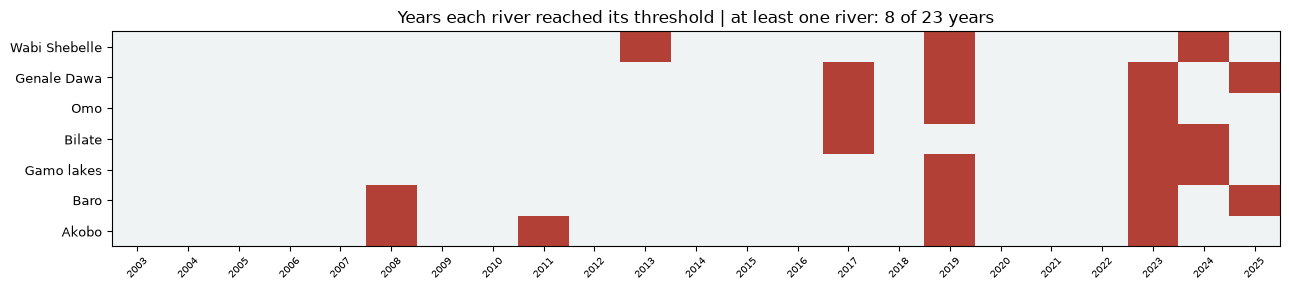

In [6]:
fig, ax = plt.subplots(figsize=(13, 3.0))
mat = active[RIVERS].T.values.astype(int)
ax.imshow(mat, cmap=mcolors.ListedColormap(["#f0f3f3", "#B34036"]), aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(N_YEARS)); ax.set_xticklabels(YEARS, fontsize=7, rotation=45)
ax.set_yticks(range(len(RIVERS))); ax.set_yticklabels(RIVERS, fontsize=9)
ax.set_title(f"Years each river reached its threshold | at least one river: {len(union_years)} of {N_YEARS} years")
plt.tight_layout(); plt.show()

## How the per-river depth was chosen

The working group's constraints were: ranking per river, an any-river trigger,
and an overall activation frequency of 1-in-3. With seven rivers these cannot
all hold at a per-river top third: the union activates in 18 of 23 years
(1-in-1.3). The candidates compared, with the impact records available at the
time (EM-DAT and CERF national flood years; FloodScan is Somali zones only):

In [7]:
EMDAT_YEARS = {2006, 2007, 2008, 2011, 2015, 2019, 2023}
CERF_YEARS = {2006, 2018, 2020, 2023}
FS5_SOMALI = {2006, 2011, 2017, 2023}  # asserted against the rebuilt FloodScan RP5 years in the impact cell

def option(tag, years):
    ys = set(years)
    return {
        "rule": tag, "n_activations": len(ys),
        "overall_rp": round((N_YEARS + 1) / len(ys), 2) if ys else np.inf,
        "emdat": f"{len(ys & EMDAT_YEARS)} of {len(EMDAT_YEARS)}",
        "cerf": f"{len(ys & CERF_YEARS)} of {len(CERF_YEARS)}",
        "floodscan_rp5_somali": f"{len(ys & FS5_SOMALI)} of {len(FS5_SOMALI)}",
        "years": ", ".join(str(y) for y in sorted(ys)),
    }

opts = []
for top_n in [3, 4, 8]:
    thr_n = river_stat.apply(lambda col: col.sort_values(ascending=False).iloc[top_n - 1])
    act_n = river_stat.ge(thr_n, axis=1)
    opts.append(option(f"any river, per-river top {top_n} (indiv 1-in-{(N_YEARS + 1) / top_n:.0f})",
                       act_n.index[act_n.any(axis=1)].tolist()))
thr8 = river_stat.apply(lambda col: col.sort_values(ascending=False).iloc[7])
act8 = river_stat.ge(thr8, axis=1)
for k in [3, 4]:
    opts.append(option(f"top third per river, at least {k} of 7 rivers together",
                       act8.index[act8.sum(axis=1) >= k].tolist()))
pd.DataFrame(opts)

,rule,n_activations,overall_rp,emdat,cerf,floodscan_rp5_somali,years
0,"any river, per-river top 3 (indiv 1-in-8)",8,3.00,4 of 7,1 of 4,3 of 4,"2008, 2011, 2013, 2017, 2019, 2023, 2024, 2025"
1,"any river, per-river top 4 (indiv 1-in-6)",10,2.40,4 of 7,2 of 4,3 of 4,"2008, 2011, 2013, 2014, 2017, 2019, 2020, 2023, 2024, 2025"
2,"any river, per-river top 8 (indiv 1-in-3)",18,1.33,6 of 7,3 of 4,3 of 4,"2005, 2007, 2008, 2010, 2011, 2012, 2013, 2014, 2015, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025"
3,"top third per river, at least 3 of 7 rivers together",10,2.40,3 of 7,2 of 4,2 of 4,"2008, 2013, 2014, 2017, 2019, 2020, 2021, 2023, 2024, 2025"
4,"top third per river, at least 4 of 7 rivers together",6,4.00,2 of 7,2 of 4,2 of 4,"2014, 2017, 2019, 2020, 2023, 2024"


The adopted depth is the first row: the only candidate meeting the overall
1-in-3 exactly while keeping the any-river shape and per-river ranking. Its
per-river bar is 1-in-8 rather than the top third; the working group accepted
that trade on 29 September 2026.

On 30 September 2026 the per-river thresholds were lowered within that rule:
each river's level drops just far enough to catch its lower-ranked seasons
that are already overall activation years, stopping at the first season
outside them. Genale Dawa (2019, next blocked 2015), Baro (2019, next blocked
2018) and Akobo (2008, next blocked 2012) each gain one season; the other four
rivers' 4th-ranked seasons fall outside the union, so their levels are
unchanged. The overall activation years and the 1-in-3.0 frequency are
unchanged by construction; no false alarms are introduced.

## Lead time

Monitoring reads the operational GloFAS ensemble median at leads 1 to 10 days.
The basis, stated plainly:

- GloFAS publishes to 30 days; 10 days is a monitoring choice, not an
  optimised value. It gives the page sight of the OND window from about
  21 September and roughly a week of warning inside the season.
- The archive evidence (notebook 03, v4 reforecast 2003-2023, Somali stations,
  scored against FloodScan events) shows forecast skill is flat across leads
  1 to 7: discharge forecasts at these points carry initial-condition memory
  rather than rainfall-forecast skill, so nothing in the record argued for a
  shorter horizon. The cell below restates that result from the stored table.
- Leads 8 to 10 are NOT validated: the reforecast archive was fetched at leads
  1 to 7 only. Nor is any lead validated for the Omo, Bilate, Gamo lakes, Baro
  or Akobo: no reforecast was fetched for those basins. Both are open gaps.

In [8]:
skill = stratus.load_parquet_from_blob(
    f"{PROJECT_PREFIX}/processed/comparison/reforecast_trigger_skill.parquet", stage=STAGE
)
sub = skill[(skill["season"] == "deyr") & (skill["prob"] == "0.5") & skill["ensemble"] & (skill["rp"] == 3)]
print("v4 reforecast, Deyr, ensemble p50 over RP3, Somali reporting points: POD by lead")
print(sub.pivot_table(index="station_id", columns="lead", values="pod").round(2).to_string())
print()
print("FAR by lead")
print(sub.pivot_table(index="station_id", columns="lead", values="far").round(2).to_string())

v4 reforecast, Deyr, ensemble p50 over RP3, Somali reporting points: POD by lead
lead             1     2     3     4     5     6     7
station_id                                            
G1904         0.00  0.00  0.00  0.00  0.00  0.00  0.00
RP_4045_0535  0.33  0.33  0.33  0.33  0.33  0.33  0.33
RP_4205_0415  0.33  0.33  0.33  0.33  0.33  0.33  0.33

FAR by lead
lead            1    2     3     4     5    6    7
station_id                                        
G1904         1.0  1.0  1.00  1.00  1.00  1.0  1.0
RP_4045_0535  0.5  0.5  0.50  0.50  0.50  0.5  0.5
RP_4205_0415  0.6  0.6  0.67  0.33  0.33  0.0  0.0


## Impact record, year by year: FloodScan, EM-DAT, CERF

- FloodScan: OND flood events in the Somali-region riverine zones (satellite;
  the extract for the new zones is not built yet and is a named gap).
- EM-DAT: flood events whose recorded locations name the riverine areas and
  whose dates touch OND. The blob snapshot is refreshed manually.
- CERF: allocations to Ethiopia with emergency type flood, by year (national).

In [9]:
from ocha_stratus import emdat
from scipy import stats
import requests

AREA_WORDS = [
    "somali", "gode", "shabelle", "shebelle", "shabele", "kelafo", "mustahil",
    "ferfer", "afder", "liben", "liban", "dolo", "genale", "dawa", "imi", "chereti",
    "omo", "dasenech", "gnangatom", "hamer", "gambel", "itang", "baro", "akobo",
    "nuer", "arba minch", "gamo", "bilate", "loka abaya",
]

# FloodScan OND event years at RP2 / RP3 / RP5, rebuilt with notebook 02's
# method (7-day centred mean, Gumbel on 1998-2025 annual maxima, runs merged
# across gaps of 14 days or less, at least 2 days long, season by peak date).
# The catalogue on blob holds RP2 and RP3 only, so those two are checked
# against it before RP5 is used.
FS_ZONES = {"ET0506": "Shabelle", "ET0509": "Liban", "ET0508": "Afder"}
fs = stratus.load_csv_from_blob(
    f"{PROJECT_PREFIX}/processed/floodscan/floodscan_somali_eth.csv", stage=STAGE
)
fs["valid_date"] = pd.to_datetime(fs["valid_date"])


def fs_event_years(rp):
    years = set()
    for pcode in FS_ZONES:
        z = fs[fs["pcode"] == pcode].set_index("valid_date")["sum"].asfreq("D").interpolate(limit=5)
        z = z.rolling(7, center=True, min_periods=4).mean()
        am = z.groupby(z.index.year).max().dropna()
        loc, scale = stats.gumbel_r.fit(am[am.index <= 2025].values)
        level = stats.gumbel_r.ppf(1 - 1 / rp, loc=loc, scale=scale)
        s = z.loc["2003-01-01":"2025-12-31"]
        above = (s >= level).fillna(False)
        if not above.any():
            continue
        grp = (above != above.shift()).cumsum()
        runs = [[c.index.min(), c.index.max()] for _, c in s[above].groupby(grp[above])]
        merged = [runs[0]]
        for a, b in runs[1:]:
            if (a - merged[-1][1]).days <= 14:
                merged[-1][1] = b
            else:
                merged.append([a, b])
        for a, b in merged:
            if (b - a).days + 1 < 2:
                continue
            peak = s.loc[a:b].idxmax()
            if peak.month in OND:
                years.add(int(peak.year))
    return sorted(years)


fs_years = {rp: fs_event_years(rp) for rp in [2, 3, 5]}
cat = stratus.load_parquet_from_blob(
    f"{PROJECT_PREFIX}/processed/floodscan/floodscan_event_catalogue.parquet", stage=STAGE
)
cat["peak_date"] = pd.to_datetime(cat["peak_date"])
cat_ond = cat[cat["season"] == "deyr"]
for rp in [2, 3]:
    cat_years = sorted(int(y) for y in cat_ond[cat_ond["fs_rp"] == rp]["peak_date"].dt.year.unique())
    assert fs_years[rp] == cat_years, (rp, fs_years[rp], cat_years)
assert set(fs_years[5]) == FS5_SOMALI, (fs_years[5], FS5_SOMALI)
print("FloodScan OND event years, Somali zones:", {f"RP{k}": v for k, v in fs_years.items()})

em = emdat.load_emdat_from_blob("ETH", include_historic=True, stage=STAGE)
em.columns = [c.lower().replace(" ", "_") for c in em.columns]
flood = em[em["disaster_type"].str.contains("Flood", case=False, na=False)].copy()
id_col = next(c for c in flood.columns if c.startswith("disno"))
loc_text = (
    flood["location"].fillna("") + " " + flood["admin_units"].fillna("").astype(str)
    + " " + flood["river_basin"].fillna("")
).str.lower()
flood["area_hit"] = loc_text.apply(lambda s: any(w in s for w in AREA_WORDS))
def touches_ond(r):
    sm = r.get("start_month"); em_ = r.get("end_month") or sm
    if pd.isna(sm):
        return False
    sm, em_ = int(sm), int(em_ if not pd.isna(em_) else sm)
    months, mth = set(), sm
    while True:
        months.add(mth)
        if mth == em_ or len(months) > 12: break
        mth = mth % 12 + 1
    return bool(months & set(OND))
flood["ond"] = flood.apply(touches_ond, axis=1)
em_ond = flood[flood["area_hit"] & flood["ond"] & flood["start_year"].between(2003, 2025)]
emdat_by_year = em_ond.groupby("start_year").agg(
    emdat_events=(id_col, "count"), emdat_affected=("total_affected", "sum")
)

cerf_raw = requests.get("https://cerfgms-webapi.unocha.org/v1/application/All.json", timeout=300).json()
apps = pd.json_normalize(cerf_raw["application"] if "application" in cerf_raw else cerf_raw)
apps.columns = [c.lower() for c in apps.columns]
eth = apps[apps.get("countryname", pd.Series(dtype=str)).str.contains("Ethiopia", case=False, na=False)]
fl = eth[eth.filter(like="emergency").apply(
    lambda col: col.astype(str).str.contains("flood", case=False, na=False)
).any(axis=1)].copy()
year_col = next(c for c in ["year", "allocationyear", "applicationyear"] if c in fl.columns)
amount_col = next(c for c in ["totalamountapproved", "amountapproved", "totalamount"] if c in fl.columns)
cerf_by_year = fl[fl[year_col].astype(int).between(2003, 2025)].groupby(fl[year_col].astype(int)).agg(
    cerf_allocations=(amount_col, "count"), cerf_usd=(amount_col, "sum"),
)

impact = pd.DataFrame(index=YEARS)
impact["trigger"] = [y in set(union_years) for y in YEARS]
impact["floodscan_rp3_somali"] = [y in set(fs_years[3]) for y in YEARS]
impact["floodscan_rp5_somali"] = [y in set(fs_years[5]) for y in YEARS]
impact = impact.join(emdat_by_year).join(cerf_by_year)
impact["emdat_events"] = impact["emdat_events"].fillna(0).astype(int)
impact["cerf_allocations"] = impact["cerf_allocations"].fillna(0).astype(int)
impact["cerf_usd"] = impact["cerf_usd"].fillna(0).round(0)
caught = impact[impact["trigger"]]
print(f"EM-DAT OND flood years caught: {int((caught['emdat_events'] > 0).sum())} of {int((impact['emdat_events'] > 0).sum())}")
print(f"CERF flood years caught: {int((caught['cerf_allocations'] > 0).sum())} of {int((impact['cerf_allocations'] > 0).sum())}")
print(f"FloodScan RP5 years caught: {int(caught['floodscan_rp5_somali'].sum())} of {int(impact['floodscan_rp5_somali'].sum())}")
impact

FloodScan OND event years, Somali zones: {'RP2': [2004, 2006, 2007, 2008, 2009, 2011, 2013, 2015, 2017, 2021, 2022, 2023], 'RP3': [2004, 2006, 2007, 2009, 2011, 2017, 2022, 2023], 'RP5': [2006, 2011, 2017, 2023]}


EM-DAT OND flood years caught: 4 of 8
CERF flood years caught: 1 of 4
FloodScan RP5 years caught: 3 of 4


,trigger,floodscan_rp3_somali,floodscan_rp5_somali,emdat_events,emdat_affected,cerf_allocations,cerf_usd
2003,False,False,False,0,NaN,0,0.0
2004,False,True,False,0,NaN,0,0.0
2005,False,False,False,0,NaN,0,0.0
2006,False,True,True,1,361600.0,2,4994747.0
2007,False,True,False,1,239586.0,0,0.0
2008,True,False,False,1,23831.0,0,0.0
2009,False,True,False,0,NaN,0,0.0
2010,False,False,False,0,NaN,0,0.0
2011,True,True,True,1,40200.0,0,0.0
2012,False,False,False,0,NaN,0,0.0


## Save

In [10]:
out_levels = levels.reset_index()
stratus.upload_csv_to_blob(
    out_levels, f"{PROJECT_PREFIX}/processed/glofas/ond_trigger_levels.csv", stage=STAGE
)
stratus.upload_parquet_to_blob(
    act_table.reset_index(names="year"),
    f"{PROJECT_PREFIX}/processed/comparison/ond_trigger_activations.parquet", stage=STAGE
)
stratus.upload_parquet_to_blob(
    impact.reset_index(names="year"),
    f"{PROJECT_PREFIX}/processed/comparison/ond_impact_record.parquet", stage=STAGE
)
print("saved levels, activations and impact record")

saved levels, activations and impact record
